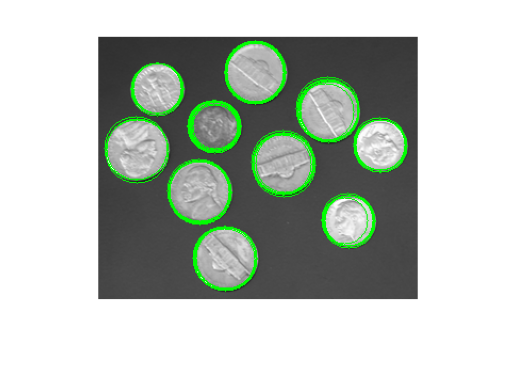

In [1]:
#Task-1
import cv2
import numpy as np
import matplotlib.pyplot as plt

def hough_circle_transform(image, min_r, max_r, min_d=50, thres1=50, thres2=150, threshold=160):
    img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    acc = np.zeros((image.shape[0], image.shape[1], max_r - min_r+1), dtype=np.uint8)
    edge = cv2.Canny(blur, thres1, thres2)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            if edge[y, x] != 0:  
                for r in range(min_r, max_r + 1):
                    for theta in range(0, 360):  
                        a = int(x - r * np.cos(np.deg2rad(theta)))
                        b = int(y - r * np.sin(np.deg2rad(theta)))
                        if a >= 0 and a < image.shape[1] and b >= 0 and b < image.shape[0]:
                            acc[b, a, r - min_r] += 1

    circles = []
    for r in range(max_r - min_r + 1):
        for y in range(image.shape[0]):
            for x in range(image.shape[1]):
                if acc[y, x, r] > min_d and acc[y, x, r] > threshold:
                    circles.append((x, y, r + min_r))

    return circles

image = cv2.imread('./Images/coins.png')

min_r = 20
max_r = 45
circles = hough_circle_transform(image, min_r, max_r)
for (x, y, r) in circles:
    cv2.circle(image, (x, y), r, (0, 255, 0), 1)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()


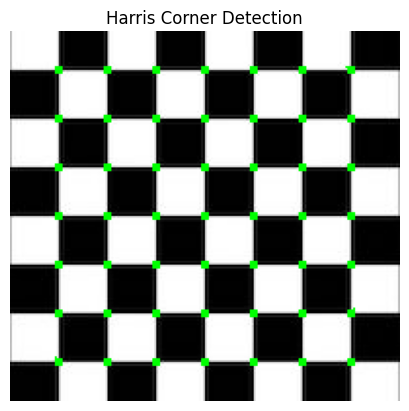

In [1]:
#Task-2
import cv2
import numpy as np
import matplotlib.pyplot as plt

def harris(image, w=3, k=0.04, threshold=0.01, border_size=5):
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    Ixx = Ix * Ix
    Ixy = Ix * Iy
    Iyy = Iy * Iy
    Sxx = cv2.blur(Ixx, (w, w))
    Sxy = cv2.blur(Ixy, (w, w))
    Syy = cv2.blur(Iyy, (w, w))
    det_M = Sxx * Syy - Sxy**2
    trace_M = Sxx + Syy
    response = det_M - k * (trace_M**2)
    response[:border_size, :] = 0
    response[-border_size:, :] = 0
    response[:, :border_size] = 0
    response[:, -border_size:] = 0
    corners = np.zeros_like(response)
    corners[response > threshold * response.max()] = 1
    return corners

def corners(image, corners):
    mark = np.copy(image)
    mark[corners == 1] = [0, 255, 0]  
    return mark

path = './Images/checkerboard.jpg'
img = cv2.imread(path)
c = harris(img)
output = corners(img, c)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Harris Corner Detection')
plt.axis('off')

plt.show()

